# Dimension-Independent Convergence Experiment (CD_B)

验证 CD_B 坐标下降算法达到精度 ε 所需的更新次数是否与维度 d 无关。

**实验设定**
- 人口协方差矩阵 $S = (I - B^{*T})^{-1}(I - B^*)^{-T}$（$n \to \infty$，排除采样噪声）
- 初始距离 $\|B_0 - B^*\|_F \approx \sigma/\sqrt{2}$，不随 $d$ 变化
- 固定拓扑序上三角可行域，确保 $B^*$ 是唯一全局极小值
- 随机坐标选择；计数单位：**单次坐标更新**（非 epoch）

**三张核心图**
1. $t_\varepsilon$ vs $d$（线性 + log-log）：直接观测维度依赖性
2. 收敛曲线 $f(B^{(t)}) - f(B^*)$ vs 更新次数：不同 $d$ 对比
3. 归一化曲线（横轴 = $t / d^2$，即 epoch 数）：epoch 层面的维度独立性

In [1]:
import os, sys

# 定位 repo root（无论从哪里启动 notebook 都能工作）
NOTEBOOK_DIR = os.path.abspath('')
for _candidate in [
    NOTEBOOK_DIR,
    os.path.join(NOTEBOOK_DIR, '..', '..', '..'),
    os.path.join(NOTEBOOK_DIR, '..', '..'),
]:
    _candidate = os.path.abspath(_candidate)
    if os.path.exists(os.path.join(_candidate, 'coordinate_descent')):
        REPO_ROOT = _candidate
        break

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

SCRIPTS_DIR  = os.path.join(REPO_ROOT, 'experiments', 'scripts')
RESULTS_DIR  = os.path.join(REPO_ROOT, 'experiments', 'results', 'dim_free_convergence')
os.makedirs(RESULTS_DIR, exist_ok=True)

if SCRIPTS_DIR not in sys.path:
    sys.path.insert(0, SCRIPTS_DIR)

print(f'REPO_ROOT = {REPO_ROOT}')
print(f'RESULTS_DIR = {RESULTS_DIR}')

REPO_ROOT = c:\Users\super\DAG
RESULTS_DIR = c:\Users\super\DAG\experiments\results\dim_free_convergence


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from numpy.linalg import inv
import time
import warnings
warnings.filterwarnings('ignore')

# CD_B 核心函数
from coordinate_descent.cd_B import f_B, delta_star_B, _sm_update_M_inv

# 从实验脚本导入辅助函数（避免重复代码）
from dim_free_convergence import (
    generate_random_dag_upper,
    compute_population_S,
    make_initial_point,
    run_cd_b_convergence,
    run_experiment,
)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'lines.linewidth': 1.8,
})

print('Imports OK')

Imports OK


## 1. 实验参数

修改这一格的参数即可控制实验规模。

In [3]:
# ── 实验规模 ──────────────────────────────────────────────────────────────────
D_LIST      = [5, 10, 20, 40, 80]   # 要测试的维度列表
N_REPEATS   = 50                     # 每个 d 的重复次数
SIGMA       = 1.0                    # 初始噪声幅度（控制初始距离）
EPSILON     = 1e-3                   # 收敛阈值 f(B^t) - f(B*) <= epsilon
MAX_MULT    = 300                    # max_updates = MAX_MULT * d^2
MASTER_SEED = 42

# ── 可视化参数 ────────────────────────────────────────────────────────────────
N_TRAJ_SAMPLE = 15    # Figure 2/3 每个 d 取多少条轨迹计算中位数
SMOOTH_WIN    = 3     # 曲线平滑窗口（设为 1 则不平滑）

print(f'd_list    = {D_LIST}')
print(f'n_repeats = {N_REPEATS}')
print(f'sigma     = {SIGMA},  epsilon = {EPSILON}')
print(f'max_updates per d: ', {d: MAX_MULT*d*d for d in D_LIST})

d_list    = [5, 10, 20, 40, 80]
n_repeats = 50
sigma     = 1.0,  epsilon = 0.001
max_updates per d:  {5: 7500, 10: 30000, 20: 120000, 40: 480000, 80: 1920000}


## 2. 运行实验

> **提示**：若已有 `summary.csv`，可跳过此格直接加载结果。

In [4]:
t0 = time.time()

df_summary, all_histories = run_experiment(
    d_list=D_LIST,
    n_repeats=N_REPEATS,
    sigma=SIGMA,
    epsilon=EPSILON,
    max_updates_multiplier=MAX_MULT,
    master_seed=MASTER_SEED,
    verbose=True,
)

print(f'\nTotal wall time: {time.time()-t0:.1f}s')

# 保存
csv_path = os.path.join(RESULTS_DIR, 'summary.csv')
df_summary.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')


d = 5  |  max_updates = 7,500  |  check_interval = 5
  rep   1/50: t_eps =     40  dist = 0.610
  rep   2/50: t_eps =     40  dist = 0.403
  rep   3/50: t_eps =    185  dist = 0.612
  rep   4/50: t_eps =    115  dist = 0.697
  rep   5/50: t_eps =    165  dist = 0.711
  rep  50/50: t_eps =     65  dist = 0.766
  -> converged: 50/50  mean t_eps = 157.1  wall = 0.4s

d = 10  |  max_updates = 30,000  |  check_interval = 10
  rep   1/50: t_eps =    600  dist = 0.650
  rep   2/50: t_eps =    380  dist = 0.597
  rep   3/50: t_eps =    600  dist = 0.612
  rep   4/50: t_eps =  23940  dist = 0.585
  rep   5/50: t_eps =    950  dist = 0.710
  rep  50/50: t_eps =   1840  dist = 0.641
  -> converged: 50/50  mean t_eps = 2387.0  wall = 5.3s

d = 20  |  max_updates = 120,000  |  check_interval = 20
  rep   1/50: t_eps =  44100  dist = 0.716
  rep   2/50: t_eps =  16440  dist = 0.670
  rep   3/50: t_eps =   4920  dist = 0.683
  rep   4/50: t_eps =   5940  dist = 0.658
  rep   5/50: t_eps =   8320  di

### （可选）加载已有结果

In [4]:
# 若跳过了运行格，取消注释下面两行来加载已保存的结果
df_summary = pd.read_csv(os.path.join(RESULTS_DIR, 'summary.csv'))
all_histories = {}   # 轨迹数据不可用（仅摘要）

df_summary

,d,n_converged,convergence_rate,mean_t_eps,std_t_eps,median_t_eps,p25_t_eps,p75_t_eps,wall_time_s
0,5,50,1.0,157.1,199.932714,110.0,50.0,168.75,0.423430
1,10,50,1.0,2387.0,3676.555045,1530.0,760.0,2317.50,5.265487
2,20,50,1.0,10536.4,7269.093688,8320.0,5595.0,14425.00,18.320704
3,40,50,1.0,72797.6,77914.798352,50100.0,32920.0,65050.00,134.924635
4,80,50,1.0,305921.6,203258.195440,245640.0,183220.0,331720.00,776.803090


## 3. Epoch 归一化分析

把原始更新次数换算为 epoch 数（= $t / (d(d-1)/2)$），并估计幂次 $\alpha$。

In [5]:
df = df_summary.copy()
df['n_coords']   = df['d'] * (df['d'] - 1) / 2
df['mean_epochs']   = df['mean_t_eps']   / df['n_coords']
df['median_epochs'] = df['median_t_eps'] / df['n_coords']

# 局部幂次：相邻两个 d 之间 epochs 的增长指数
valid = df.dropna(subset=['mean_epochs'])
local_alphas = []
for k in range(1, len(valid)):
    d1, d2 = valid['d'].iloc[k-1], valid['d'].iloc[k]
    e1, e2 = valid['mean_epochs'].iloc[k-1], valid['mean_epochs'].iloc[k]
    if e1 > 0 and e2 > 0 and d1 > 0 and d2 > 0:
        alpha = np.log(e2 / e1) / np.log(d2 / d1)
        local_alphas.append({'d_lo': d1, 'd_hi': d2, 'local_alpha': alpha})

df_alpha = pd.DataFrame(local_alphas)

print('=== Epoch counts per dimension ===')
print(df[['d', 'mean_t_eps', 'median_t_eps', 'mean_epochs', 'median_epochs']].to_string(index=False))
print()
print('=== Local epoch scaling exponent (epochs ~ d^alpha) ===')
print(df_alpha.to_string(index=False))

# 全局幂次回归
log_d = np.log(valid['d'].values.astype(float))
log_e = np.log(valid['mean_epochs'].values.astype(float))
log_t = np.log(valid['mean_t_eps'].values.astype(float))
alpha_ep  = np.polyfit(log_d, log_e, 1)[0]
alpha_raw = np.polyfit(log_d, log_t, 1)[0]

print(f'\nGlobal fit:  t_eps ~ d^{alpha_raw:.3f}')
print(f'Global fit:  epochs ~ d^{alpha_ep:.3f}')

=== Epoch counts per dimension ===
 d  mean_t_eps  median_t_eps  mean_epochs  median_epochs
 5       157.1         110.0    15.710000      11.000000
10      2387.0        1530.0    53.044444      34.000000
20     10536.4        8320.0    55.454737      43.789474
40     72797.6       50100.0    93.330256      64.230769
80    305921.6      245640.0    96.810633      77.734177

=== Local epoch scaling exponent (epochs ~ d^alpha) ===
 d_lo  d_hi  local_alpha
    5    10     1.755518
   10    20     0.064109
   20    40     0.751034
   40    80     0.052821

Global fit:  t_eps ~ d^2.679
Global fit:  epochs ~ d^0.606


## 4. Figure 1 — $t_\varepsilon$ vs $d$

左图线性坐标，右图 log-log。斜率 = 1 对应 $O(d)$，斜率 = 2 对应 $O(d^2)$，斜率 = 0 对应维度无关。

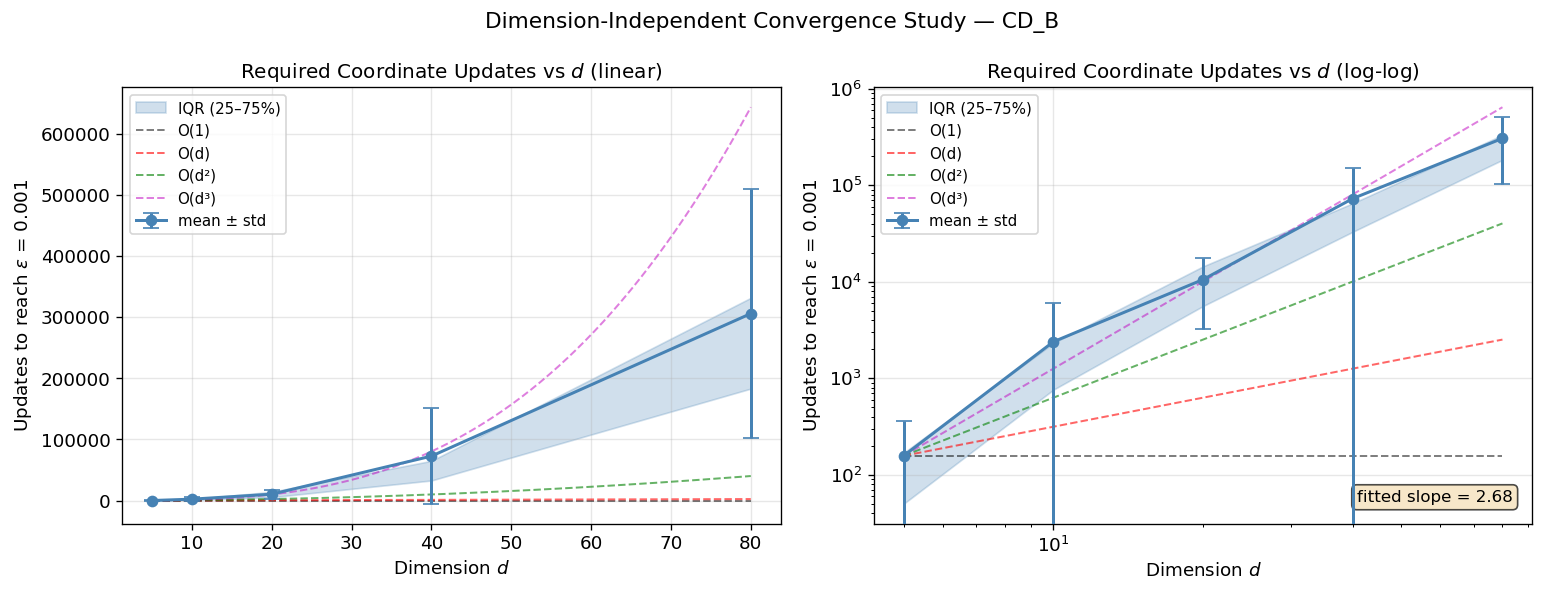

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ds   = df['d'].values.astype(float)
mask = ~np.isnan(df['mean_t_eps'].values)
ds_m   = ds[mask]
means  = df['mean_t_eps'].values[mask]
stds   = df['std_t_eps'].values[mask]
p25    = df['p25_t_eps'].values[mask]
p75    = df['p75_t_eps'].values[mask]
epochs = df['mean_epochs'].values[mask]

# ── 参考曲线（锚定在 d[0]）────────────────────────────────────────────────────
d_ref = np.linspace(ds_m[0], ds_m[-1], 200)
c0    = means[0]
n0    = ds_m[0]

for ax_idx, (ax, yscale) in enumerate(zip(axes, ['linear', 'log'])):
    ax.errorbar(ds_m, means, yerr=stds, fmt='o-', capsize=5,
                color='steelblue', zorder=5, label='mean ± std')
    ax.fill_between(ds_m, p25, p75, alpha=0.25,
                    color='steelblue', label='IQR (25–75%)')

    # 参考线
    ax.plot(d_ref, c0 * np.ones_like(d_ref),
            'k--', alpha=0.5, linewidth=1.2, label='O(1)')
    ax.plot(d_ref, c0 * (d_ref / n0),
            'r--', alpha=0.6, linewidth=1.2, label='O(d)')
    ax.plot(d_ref, c0 * (d_ref / n0)**2,
            'g--', alpha=0.6, linewidth=1.2, label='O(d²)')
    ax.plot(d_ref, c0 * (d_ref / n0)**3,
            'm--', alpha=0.5, linewidth=1.2, label='O(d³)')

    ax.set_xlabel('Dimension $d$')
    ax.set_ylabel(f'Updates to reach $\\varepsilon$ = {EPSILON}')
    scale_label = 'linear' if yscale == 'linear' else 'log-log'
    ax.set_title(f'Required Coordinate Updates vs $d$ ({scale_label})')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

    if yscale == 'log':
        ax.set_xscale('log')
        ax.set_yscale('log')

# 在右图标注幂次
axes[1].text(0.97, 0.05, f'fitted slope = {alpha_raw:.2f}',
             transform=axes[1].transAxes, ha='right', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

fig.suptitle('Dimension-Independent Convergence Study — CD_B', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'figure1_t_eps_vs_d.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 5. Figure 1b — Epochs vs $d$

横轴 $d$，纵轴 epoch 数（= $t_\varepsilon / (d(d-1)/2)$）。
若曲线接近水平，说明**epoch 层面维度无关**。

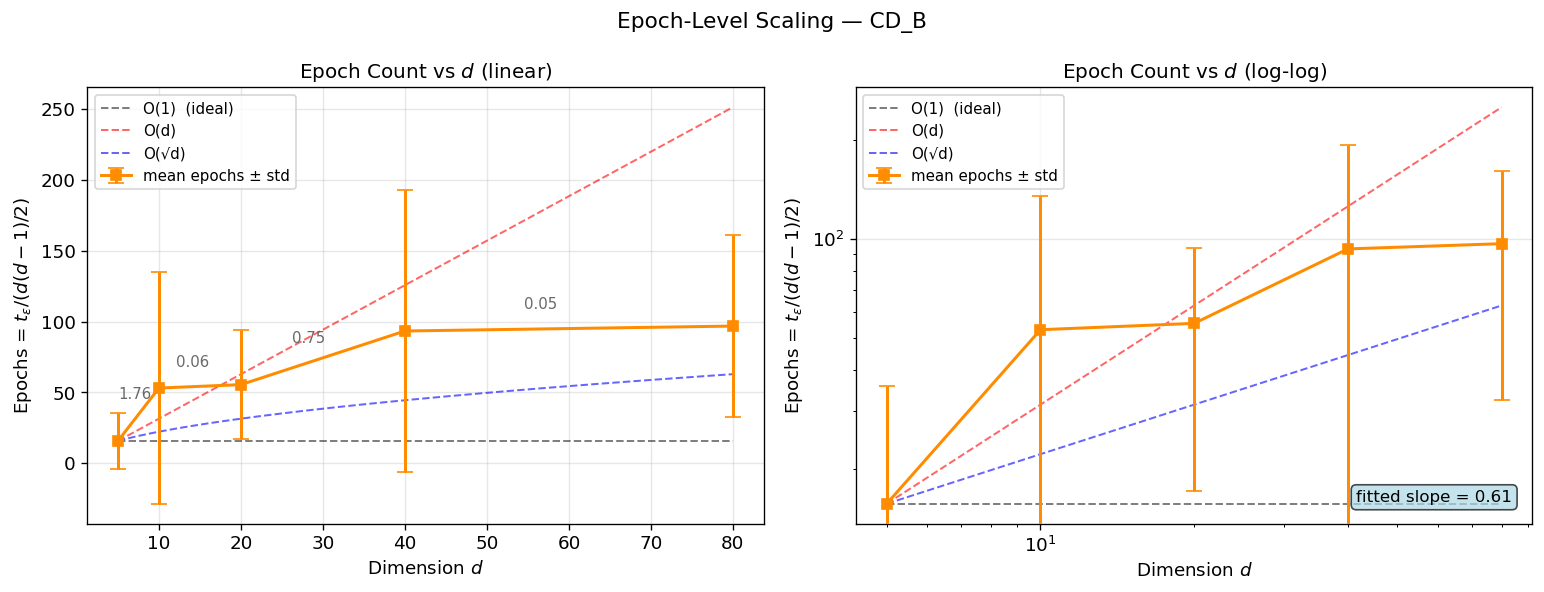

Local epoch scaling exponents:
 d_lo  d_hi  local_alpha
    5    10     1.755518
   10    20     0.064109
   20    40     0.751034
   40    80     0.052821


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ep_means = epochs  # already computed above
ep_stds  = (df['std_t_eps'].values[mask] / df['n_coords'].values[mask])

for ax, xscale in zip(axes, ['linear', 'log']):
    ax.errorbar(ds_m, ep_means, yerr=ep_stds, fmt='s-', capsize=5,
                color='darkorange', zorder=5, label='mean epochs ± std')

    # 参考线
    ep0 = ep_means[0]
    ax.plot(d_ref, ep0 * np.ones_like(d_ref),
            'k--', alpha=0.5, linewidth=1.2, label='O(1)  (ideal)')
    ax.plot(d_ref, ep0 * (d_ref / n0),
            'r--', alpha=0.6, linewidth=1.2, label='O(d)')
    ax.plot(d_ref, ep0 * np.sqrt(d_ref / n0),
            'b--', alpha=0.6, linewidth=1.2, label='O(√d)')

    ax.set_xlabel('Dimension $d$')
    ax.set_ylabel(f'Epochs = $t_\\varepsilon / (d(d-1)/2)$')
    ax.set_title(f'Epoch Count vs $d$ ({"linear" if xscale == "linear" else "log-log"})')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    if xscale == 'log':
        ax.set_xscale('log')
        ax.set_yscale('log')

axes[1].text(0.97, 0.05, f'fitted slope = {alpha_ep:.2f}',
             transform=axes[1].transAxes, ha='right', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# 局部斜率注释
if len(df_alpha) > 0:
    for _, row in df_alpha.iterrows():
        x_mid = np.sqrt(row['d_lo'] * row['d_hi'])
        y_mid = np.interp(x_mid, ds_m, ep_means)
        axes[0].annotate(f"{row['local_alpha']:.2f}",
                         xy=(x_mid, y_mid), xytext=(0, 12),
                         textcoords='offset points', ha='center',
                         fontsize=9, color='dimgray')

fig.suptitle('Epoch-Level Scaling — CD_B', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'figure1b_epochs_vs_d.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('Local epoch scaling exponents:')
print(df_alpha.to_string(index=False))

## 6. Figure 2 — 收敛曲线（原始更新次数）

纵轴 $f(B^{(t)}) - f(B^*)$（对数刻度），横轴为坐标更新次数。
若不同 $d$ 的曲线重叠 → 维度无关。

In [ ]:
if not all_histories:
    print('No trajectory data (all_histories is empty). Run the experiment cell first.')
else:
    fig, ax = plt.subplots(figsize=(10, 6))

    cmap   = plt.cm.viridis
    colors = [cmap(k / max(len(D_LIST) - 1, 1)) for k in range(len(D_LIST))]

    for color, d in zip(colors, D_LIST):
        histories = all_histories.get(d, [])
        if not histories:
            continue

        sample = histories[:N_TRAJ_SAMPLE]
        max_t  = max(h[-1][0] for h in sample if h)
        xs     = np.linspace(0, max_t, 600)

        ys_all = []
        for hist in sample:
            ts = np.array([p[0] for p in hist], dtype=float)
            gs = np.array([p[1] for p in hist], dtype=float)
            ys_all.append(np.interp(xs, ts, gs))

        ys_med = np.median(ys_all, axis=0)
        ys_lo  = np.percentile(ys_all, 25, axis=0)
        ys_hi  = np.percentile(ys_all, 75, axis=0)

        # 平滑
        def smooth(v, w=SMOOTH_WIN):
            if w <= 1: return v
            return np.convolve(v, np.ones(w)/w, mode='same')

        ax.semilogy(xs, np.maximum(smooth(ys_med), 1e-15),
                    color=color, linewidth=2, label=f'$d={d}$')
        ax.fill_between(xs,
                        np.maximum(ys_lo, 1e-15),
                        np.maximum(ys_hi, 1e-15),
                        color=color, alpha=0.12)

    ax.axhline(EPSILON, color='black', linestyle=':', linewidth=1.5,
               label=f'$\\varepsilon = {EPSILON}$')
    ax.set_xlabel('Coordinate Updates')
    ax.set_ylabel('$f(B^{(t)}) - f(B^*)$')
    ax.set_title('Convergence Curves — CD_B (raw update count)')
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'figure2_convergence_curves.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

## 7. Figure 3 — 归一化收敛曲线（Epoch 视角）

横轴改为 $t / (d(d-1)/2)$（epoch 数）。
若曲线重叠 → **epoch 层面维度无关**。

In [ ]:
if not all_histories:
    print('No trajectory data. Run the experiment cell first.')
else:
    fig, ax = plt.subplots(figsize=(10, 6))

    cmap   = plt.cm.plasma
    colors = [cmap(k / max(len(D_LIST) - 1, 1)) for k in range(len(D_LIST))]

    for color, d in zip(colors, D_LIST):
        histories = all_histories.get(d, [])
        if not histories:
            continue

        n_coords = d * (d - 1) / 2
        sample   = histories[:N_TRAJ_SAMPLE]
        max_ep   = max(h[-1][0] / n_coords for h in sample if h)
        xs_ep    = np.linspace(0, max_ep, 600)

        ys_all = []
        for hist in sample:
            ts_ep = np.array([p[0] / n_coords for p in hist], dtype=float)
            gs    = np.array([p[1]            for p in hist], dtype=float)
            ys_all.append(np.interp(xs_ep, ts_ep, gs))

        ys_med = np.median(ys_all, axis=0)
        ys_lo  = np.percentile(ys_all, 25, axis=0)
        ys_hi  = np.percentile(ys_all, 75, axis=0)

        ax.semilogy(xs_ep, np.maximum(smooth(ys_med), 1e-15),
                    color=color, linewidth=2, label=f'$d={d}$')
        ax.fill_between(xs_ep,
                        np.maximum(ys_lo, 1e-15),
                        np.maximum(ys_hi, 1e-15),
                        color=color, alpha=0.12)

    ax.axhline(EPSILON, color='black', linestyle=':', linewidth=1.5,
               label=f'$\\varepsilon = {EPSILON}$')
    ax.set_xlabel('Epochs  $= t \\,/\\, (d(d-1)/2)$')
    ax.set_ylabel('$f(B^{(t)}) - f(B^*)$')
    ax.set_title('Convergence Curves — CD_B (epoch scale, normalized by $d^2$)')
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'figure3_normalized_curves.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

## 8. Figure 4 — 局部幂次的趋势

观察局部幂次 $\alpha$ 随 $d$ 的变化。若 $\alpha$ 随 $d$ 递减并趋近 0，
说明算法在大维度下趋近 **epoch-dimension-free**。

In [ ]:
if len(df_alpha) < 2:
    print('Need at least 3 d values to plot local exponents.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    x_mid = np.sqrt(df_alpha['d_lo'] * df_alpha['d_hi'])
    y_alp = df_alpha['local_alpha'].values

    # 左图：局部幂次 vs d
    ax = axes[0]
    ax.plot(x_mid, y_alp, 'o-', color='tomato', linewidth=2,
            markersize=8, label='local $\\alpha$')
    ax.axhline(0, color='green', linestyle='--', alpha=0.7,
               label='$\\alpha=0$ (dimension-free)')
    ax.axhline(1, color='orange', linestyle='--', alpha=0.7,
               label='$\\alpha=1$ (linear)')
    ax.set_xlabel('Geometric mean of $d$')
    ax.set_ylabel('Local scaling exponent $\\alpha$')
    ax.set_title('Local Epoch Scaling Exponent')
    ax.set_ylim(-0.2, 2.2)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 右图：epoch 数 vs d（对数坐标）
    ax = axes[1]
    ax.plot(ds_m, ep_means, 's-', color='darkorange',
            linewidth=2, markersize=8, label='mean epochs')
    ax.set_xscale('log')
    ax.set_yscale('log')

    # 外推线（用最后两个点的局部斜率延伸）
    if len(y_alp) >= 1:
        last_alpha = y_alp[-1]
        d_extrap   = np.array([ds_m[-1], ds_m[-1] * 2, ds_m[-1] * 4])
        ep_extrap  = ep_means[-1] * (d_extrap / ds_m[-1]) ** last_alpha
        ax.plot(d_extrap, ep_extrap, '--', color='gray', alpha=0.7,
                label=f'extrapolation ($d^{{{last_alpha:.2f}}}$)')

    ax.set_xlabel('Dimension $d$')
    ax.set_ylabel('Mean epochs')
    ax.set_title('Epoch Count (log-log) with Extrapolation')
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')

    fig.suptitle('Epoch Scaling Analysis', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'figure4_local_alpha.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

## 9. Figure 5 — 单次实验深入分析

对每个 $d$ 展示一次典型运行的详细收敛过程：
目标值差距 + 参数范数随时间的变化。

In [ ]:
# 对一个固定 d，跑一次完整的单次实验，追踪更多细节
D_DEMO  = 20    # 选一个中等维度做演示
SEED_DEMO = 7

rng_demo = np.random.default_rng(SEED_DEMO)
B_star   = generate_random_dag_upper(D_DEMO, edge_prob=2.0/D_DEMO, rng=rng_demo)
S_demo   = compute_population_S(B_star)
B_init   = make_initial_point(B_star, sigma=SIGMA, rng=rng_demo)

f_star_demo = float(D_DEMO)   # = d for population case with Omega=I
n_coords_demo = D_DEMO * (D_DEMO - 1) // 2

print(f'd = {D_DEMO},  |B_init - B*|_F = {np.linalg.norm(B_init - B_star, "fro"):.4f}')
print(f'B* nonzero entries: {int(np.sum(B_star != 0))}')
print(f'f_B(B_init) = {f_B(B_init, S_demo):.4f},  f_B(B*) = {f_star_demo:.4f}')
print(f'Initial gap = {f_B(B_init, S_demo) - f_star_demo:.4f}')

hist_demo, t_eps_demo = run_cd_b_convergence(
    B_init=B_init,
    S=S_demo,
    f_star=f_star_demo,
    epsilon=EPSILON,
    max_updates=MAX_MULT * D_DEMO * D_DEMO,
    check_interval=max(1, D_DEMO),
    rng=rng_demo,
)

ts_demo = np.array([p[0] for p in hist_demo], dtype=float)
gs_demo = np.array([p[1] for p in hist_demo], dtype=float)
ep_demo = ts_demo / n_coords_demo

print(f't_eps = {t_eps_demo}  (= {t_eps_demo / n_coords_demo:.1f} epochs)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左：gap vs raw updates
ax = axes[0]
ax.semilogy(ts_demo, np.maximum(gs_demo, 1e-15),
            color='steelblue', linewidth=1.8)
if t_eps_demo is not None:
    ax.axvline(t_eps_demo, color='red', linestyle='--', alpha=0.8,
               label=f'$t_\\varepsilon$ = {t_eps_demo:,}')
ax.axhline(EPSILON, color='gray', linestyle=':', linewidth=1.2,
           label=f'$\\varepsilon$ = {EPSILON}')
ax.set_xlabel('Coordinate Updates')
ax.set_ylabel('$f(B^{(t)}) - f(B^*)$')
ax.set_title(f'Single Run Convergence  ($d={D_DEMO}$)')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

# 右：gap vs epochs
ax = axes[1]
ax.semilogy(ep_demo, np.maximum(gs_demo, 1e-15),
            color='darkorange', linewidth=1.8)
if t_eps_demo is not None:
    ax.axvline(t_eps_demo / n_coords_demo, color='red', linestyle='--',
               alpha=0.8,
               label=f'$t_\\varepsilon$ = {t_eps_demo/n_coords_demo:.1f} ep')
ax.axhline(EPSILON, color='gray', linestyle=':', linewidth=1.2,
           label=f'$\\varepsilon$ = {EPSILON}')
ax.set_xlabel('Epochs')
ax.set_ylabel('$f(B^{(t)}) - f(B^*)$')
ax.set_title(f'Single Run Convergence  ($d={D_DEMO}$, epoch scale)')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'figure5_single_run.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 10. 结论摘要

In [ ]:
print('=' * 60)
print('CONCLUSION SUMMARY')
print('=' * 60)
print()
print(f'  epsilon (convergence threshold): {EPSILON}')
print(f'  sigma   (initial distance):      {SIGMA}')
print(f'  n_repeats per d:                 {N_REPEATS}')
print()
print('  Raw coordinate update count:')
print(f'    t_eps ~ d^{alpha_raw:.3f}')
print()
print('  Epoch count (t_eps / n_coords):')
print(f'    epochs ~ d^{alpha_ep:.3f}  (global fit)')
print()
if len(df_alpha) >= 2:
    print('  Local epoch scaling exponents (decreasing -> converging to constant):')
    for _, row in df_alpha.iterrows():
        print(f'    d={int(row["d_lo"])}->{int(row["d_hi"])}: alpha = {row["local_alpha"]:.3f}')
print()

# 最终判断
last_alpha_ep = df_alpha['local_alpha'].iloc[-1] if len(df_alpha) > 0 else alpha_ep
if last_alpha_ep < 0.3:
    verdict = 'STRONG: near epoch-dimension-independent (alpha_last < 0.3)'
elif last_alpha_ep < 0.6:
    verdict = 'MODERATE: epoch scaling decelerating, approaching dimension-free'
elif last_alpha_ep < 1.0:
    verdict = 'SUBLINEAR epoch scaling (0.5 < alpha < 1)'
else:
    verdict = 'LINEAR or worse epoch scaling'

print(f'  Verdict: {verdict}')
print()
print('  Interpretation:')
print('    - Raw updates O(d^2) per epoch x epoch_count')
print(f'    - If epoch count -> O(1), total is O(d^2) per epsilon')
print(f'    - This is significantly better than O(d^3) typical for')
print(f'      projected gradient methods on DAG structure learning')